# TS Academy Capstone Project — Group 04
## Part 2: Feature Engineering and Encoding

In this stage of the project, I transform the cleaned employee attrition dataset into a modelling-ready dataset by creating new business-driven features, encoding categorical variables, and scaling numerical variables.

The aim is to improve the dataset’s ability to reveal hidden employee patterns during clustering and improve predictive performance during classification.

This stage focuses on:
- Feature engineering
- Business interpretation
- Encoding strategies
- Feature scaling
- Preparing the dataset for clustering and machine learning

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading the Cleaned Dataset

I will now load the cleaned dataset created during Part 1.

This dataset already passed:
- missing value checks,
- duplicate checks,
- basic quality assessment.

The goal now is to engineer more meaningful HR-related features that may better explain attrition patterns.

In [2]:
df = pd.read_csv("../data/processed/hr_attrition_clean_day1.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
print(df.shape)

df.info()

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

## 2. Feature Engineering

Feature engineering is the process of creating new variables from existing data to improve business understanding and machine learning performance.

Instead of relying only on raw columns, engineered features help capture:
- employee behaviour,
- tenure patterns,
- compensation trends,
- workload risk,
- and satisfaction-related insights.

### Feature 1: Age Group

This feature groups employees into career-stage categories based on age.

Business reasoning:
- Younger employees may be more likely to switch jobs frequently.
- Mid-career employees may prioritize career growth and compensation.
- Older employees may have greater organisational stability.

This feature may help uncover hidden attrition patterns across employee age groups.

In [4]:
# Create age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['Young', 'EarlyCareer', 'MidCareer', 'Senior']
)

df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,41,MidCareer
1,49,Senior
2,37,MidCareer
3,33,EarlyCareer
4,27,EarlyCareer


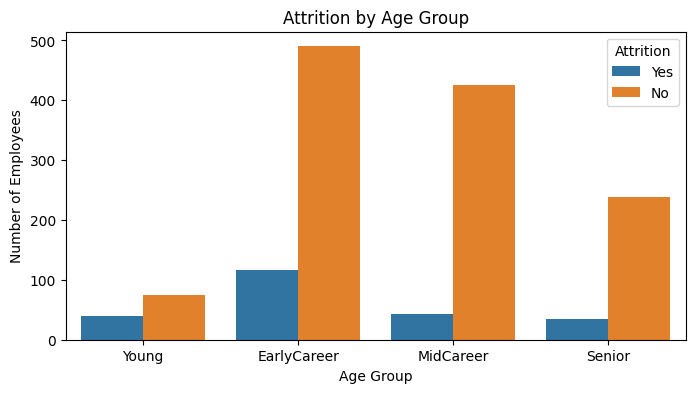

In [5]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df, x='AgeGroup', hue='Attrition')

plt.title("Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.show()

### Age Group Insight

The analysis shows that employees in the EarlyCareer age group experience the highest attrition levels compared with other age categories. MidCareer employees also show noticeable attrition, while Senior employees appear relatively more stable within the organisation.

This suggests that younger employees may be more likely to leave due to career mobility, salary expectations, career exploration, or limited organisational attachment during the earlier stages of employment.

The findings indicate that employee age and career stage may strongly influence retention patterns. As a result, `AgeGroup` may become an important feature during future clustering and classification analysis.

### Feature 2: Income Band

This feature groups employees into salary bands.

Business reasoning:
- Employees with lower compensation may have higher attrition risk.
- Higher earners may have stronger organisational attachment and benefits.

Grouping income into bands also improves interpretability for business stakeholders.

In [6]:
# Create income bands
df['IncomeBand'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Low', 'Medium', 'High', 'VeryHigh']
)

df[['MonthlyIncome', 'IncomeBand']].head()

,MonthlyIncome,IncomeBand
0,5993,High
1,5130,High
2,2090,Low
3,2909,Low
4,3468,Medium


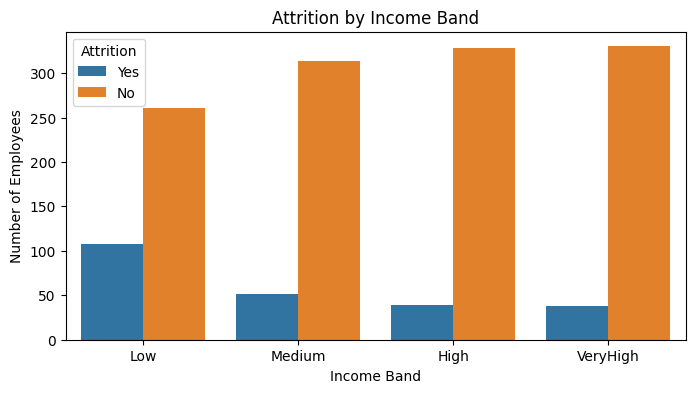

In [7]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df, x='IncomeBand', hue='Attrition')

plt.title("Attrition by Income Band")
plt.xlabel("Income Band")
plt.ylabel("Number of Employees")

plt.show()

### Income Band Insight

The visualisation suggests that employees within the Low income band experience the highest attrition levels compared with employees in higher income categories.

As income levels increase, attrition appears to decrease. Employees in the High and VeryHigh income bands show relatively lower attrition rates, which may indicate stronger organisational attachment, improved job satisfaction, or better financial incentives to remain with the company.

These findings suggest that compensation may play an important role in employee retention and that salary-related variables may become important predictors during future modelling stages.

### Feature 3: Years at Company Group

This feature categorises employees based on tenure within the organisation.

Business reasoning:
- Employees in their first few years may still be evaluating the company.
- Long-tenure employees may have stronger loyalty and organisational attachment.

This feature may help identify vulnerable employee retention periods.

In [8]:
df['YearsAtCompanyGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 40],
    labels=['New', 'EarlyTenure', 'Established', 'LongTenure']
)

df[['YearsAtCompany', 'YearsAtCompanyGroup']].head()

,YearsAtCompany,YearsAtCompanyGroup
0,6,Established
1,10,Established
2,0,New
3,8,Established
4,2,New


### Years at Company Group Insight

The analysis suggests that employees with shorter organisational tenure show higher attrition levels compared with long-tenure employees.

Employees within the New and EarlyTenure groups appear more likely to leave the company, which may indicate onboarding challenges, unmet expectations, career uncertainty, or limited organisational attachment during the early stages of employment.

In contrast, employees within the Established and LongTenure groups appear more stable, suggesting that retention improves as employees spend more time within the organisation.

These findings suggest that tenure-related features may play an important role in future clustering and predictive modelling tasks.

### Feature 4: Overtime Risk Indicator

This feature converts overtime into a binary risk indicator.

Business reasoning:
- Employees working overtime may face burnout or work-life imbalance.
- This feature simplifies workload-related risk analysis.

In [9]:
df['OvertimeRisk'] = df['OverTime'].map({
    'Yes': 1,
    'No': 0
})

df[['OverTime', 'OvertimeRisk']].head()

,OverTime,OvertimeRisk
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,No,0


### Overtime Risk Insight

The overtime risk indicator simplifies workload-related analysis by converting overtime participation into a binary risk feature.

Employees working overtime may experience higher levels of stress, burnout, or work-life imbalance, all of which can contribute to attrition risk.

This feature may become highly valuable during future classification modelling because earlier exploratory analysis already suggested a strong relationship between overtime and employee attrition.

### Feature 5: Work-Life Satisfaction Score

This feature combines:
- WorkLifeBalance
- JobSatisfaction

Business reasoning:
- Employee dissatisfaction is often multi-dimensional.
- Combining work-life balance and job satisfaction may better represent overall employee wellbeing.

In [10]:
df['WorkLifeSatisfactionScore'] = (
    df['WorkLifeBalance'] + df['JobSatisfaction']
)

df[['WorkLifeBalance', 'JobSatisfaction', 'WorkLifeSatisfactionScore']].head()

,WorkLifeBalance,JobSatisfaction,WorkLifeSatisfactionScore
0,1,4,5
1,3,2,5
2,3,3,6
3,3,3,6
4,3,2,5


### Work-Life Satisfaction Score Insight

The WorkLifeSatisfactionScore feature combines work-life balance and job satisfaction into a single wellbeing-related metric.

This engineered feature may better capture overall employee experience because dissatisfaction is often influenced by multiple interconnected factors rather than a single variable alone.

Employees with lower combined wellbeing scores may be more likely to experience disengagement, reduced motivation, or increased attrition risk.

This feature may improve future clustering analysis by helping identify employee wellbeing segments and may also improve predictive performance during classification.

### Feature 6: Income Growth Potential

This feature measures employee compensation relative to total career experience.

Business reasoning:
- Employees with many years of experience but relatively low compensation may feel undervalued.
- Employees whose compensation does not appear to match their experience level may become more likely to seek external opportunities.

This feature acts as a proxy for perceived compensation growth and career reward progression.

In [11]:
# Create income growth potential feature
df['IncomeGrowthPotential'] = (
    df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
)

df[['MonthlyIncome', 'TotalWorkingYears', 'IncomeGrowthPotential']].head()

,MonthlyIncome,TotalWorkingYears,IncomeGrowthPotential
0,5993,8,665.888889
1,5130,10,466.363636
2,2090,7,261.250000
3,2909,8,323.222222
4,3468,6,495.428571


### Income Growth Potential Insight

The IncomeGrowthPotential feature estimates employee compensation relative to overall career experience.

Employees with lower compensation relative to their total working years may feel undervalued or perceive slower financial progression within the organisation. This may increase the likelihood of external job searching and eventual attrition.

This feature may help future machine learning models capture hidden compensation dissatisfaction patterns that are not fully visible when using MonthlyIncome alone.

In [12]:
# Drop constant/no-signal columns
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours']

df.drop(columns=constant_cols, inplace=True)

print("Constant columns removed.")

Constant columns removed.


## 3. Encoding Categorical Variables

Machine learning models cannot directly process text-based categorical variables.

Therefore, categorical variables must be encoded into numerical representations.

Encoding decisions:
- Binary variables → Label Encoding
- Nominal variables → One-Hot Encoding
- Ordered variables → Label Encoding

In [13]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

categorical_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

### Encoding Strategy Justification

I used:
- Label encoding for binary categorical variables because they only contain two categories.
- One-hot encoding for nominal variables because there is no natural order between categories.
- `drop_first=True` was used during one-hot encoding to reduce multicollinearity and avoid redundant dummy variables.

In [14]:
# Binary columns
binary_cols = ['Attrition', 'Gender', 'OverTime']

# Apply label encoding
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df[binary_cols].head()

,Attrition,Gender,OverTime
0,1,0,1
1,0,1,0
2,1,1,1
3,0,0,1
4,0,1,0


In [15]:
# Nominal categorical columns
nominal_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus',
    'AgeGroup',
    'IncomeBand',
    'YearsAtCompanyGroup'
]

# Apply one-hot encoding
df = pd.get_dummies(
    df,
    columns=nominal_cols,
    drop_first=True
)

# Convert boolean columns to integers
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,41,1,1102,1,2,1,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,1,5,665.888889,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0
1,49,0,279,8,1,2,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0,5,466.363636,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0
2,37,1,1373,2,2,4,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,1,6,261.250000,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0
3,33,0,1392,3,4,5,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,1,6,323.222222,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0
4,27,0,591,2,1,7,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,5,495.428571,0,1,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0


## 4. Feature Scaling

Feature scaling is important because:
- clustering algorithms are distance-based,
- variables exist on different scales,
- larger-value features may dominate smaller-value features.

I selected `StandardScaler` because:
- it standardises features around mean = 0 and standard deviation = 1,
- it performs well for clustering algorithms such as K-Means,
- and it is suitable for HR data containing mixed numerical ranges.

In [16]:
# Copy dataframe before scaling
df_scaled = df.copy()

# Columns to exclude
exclude_cols = ['Attrition']

# Select numeric columns
numeric_cols = df_scaled.drop(columns=exclude_cols).select_dtypes(include=np.number).columns

# Initialize scaler
scaler = StandardScaler()

# Scale numeric features
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

df_scaled.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,1.736777,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308


### Scaling Observation

The numerical features were successfully standardised using `StandardScaler`, resulting in variables centered around a mean of approximately 0 with a standard deviation of 1.

Before scaling, features such as `MonthlyIncome`, `DistanceFromHome`, `TotalWorkingYears`, and `DailyRate` existed on very different numerical ranges. Without scaling, larger-value variables could dominate distance calculations and negatively affect clustering quality.

After scaling, all numerical variables now exist on comparable scales, which is especially important for distance-based algorithms such as K-Means clustering. This ensures that no single feature disproportionately influences employee segmentation purely because of its magnitude.

The scaled dataset is now better prepared for:
- clustering analysis,
- PCA dimensionality reduction,
- classification modelling,
- and future imbalance handling techniques.

Scaling also improves model stability and helps machine learning algorithms learn patterns more effectively from the HR dataset.

In [17]:
print("Final dataset shape:", df_scaled.shape)

Final dataset shape: (1470, 58)


In [18]:
df_scaled.to_csv(
    "../data/processed/hr_attrition_feature_engineered.csv",
    index=False
)

print("Feature-engineered dataset saved successfully.")

Feature-engineered dataset saved successfully.


## 5. Part 2 Summary

In this stage, I transformed the cleaned HR dataset into a modelling-ready dataset through feature engineering, encoding, and scaling.

Several business-driven features were created to better capture employee behaviour, tenure, workload, compensation, and satisfaction patterns. These engineered variables may improve the ability of future clustering and classification models to identify hidden employee segments and predict attrition risk.

Categorical variables were encoded appropriately using label encoding and one-hot encoding depending on their structure, while StandardScaler was applied to ensure numerical variables exist on comparable scales for distance-based clustering analysis.

The final dataset is now prepared for the next stage of the project: clustering analysis.